In [237]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

In [238]:
#load the data

df       = pd.read_csv('train-test.csv')
df_prod  = pd.read_csv('validation.csv')
template = pd.read_csv('validation-predictions-template.csv')

In [239]:
#EDA

df.info() #missing data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [240]:
df.describe() # weight negative values

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


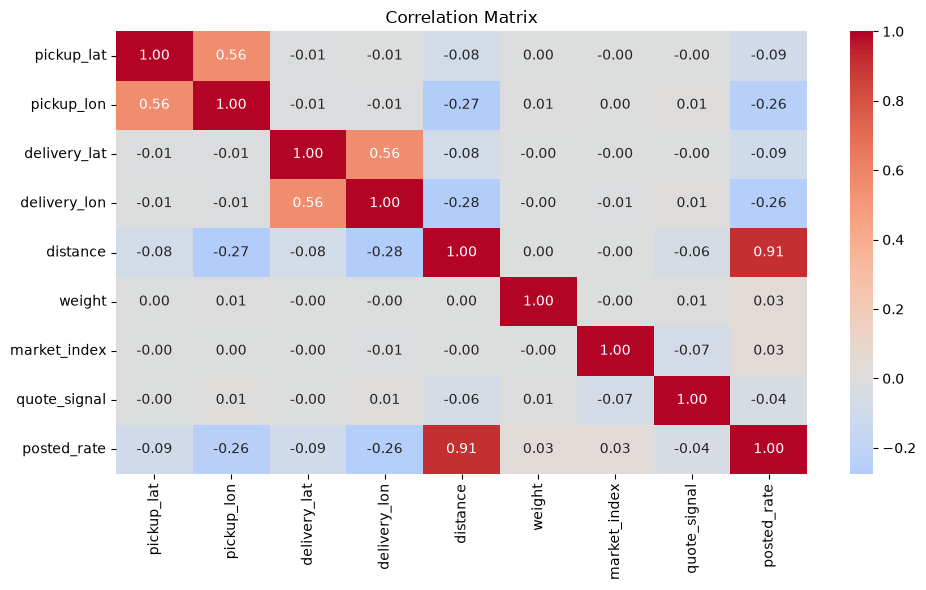

Saved: correlation_matrix.png


In [242]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=110)
plt.show()
print("Saved: correlation_matrix.png")

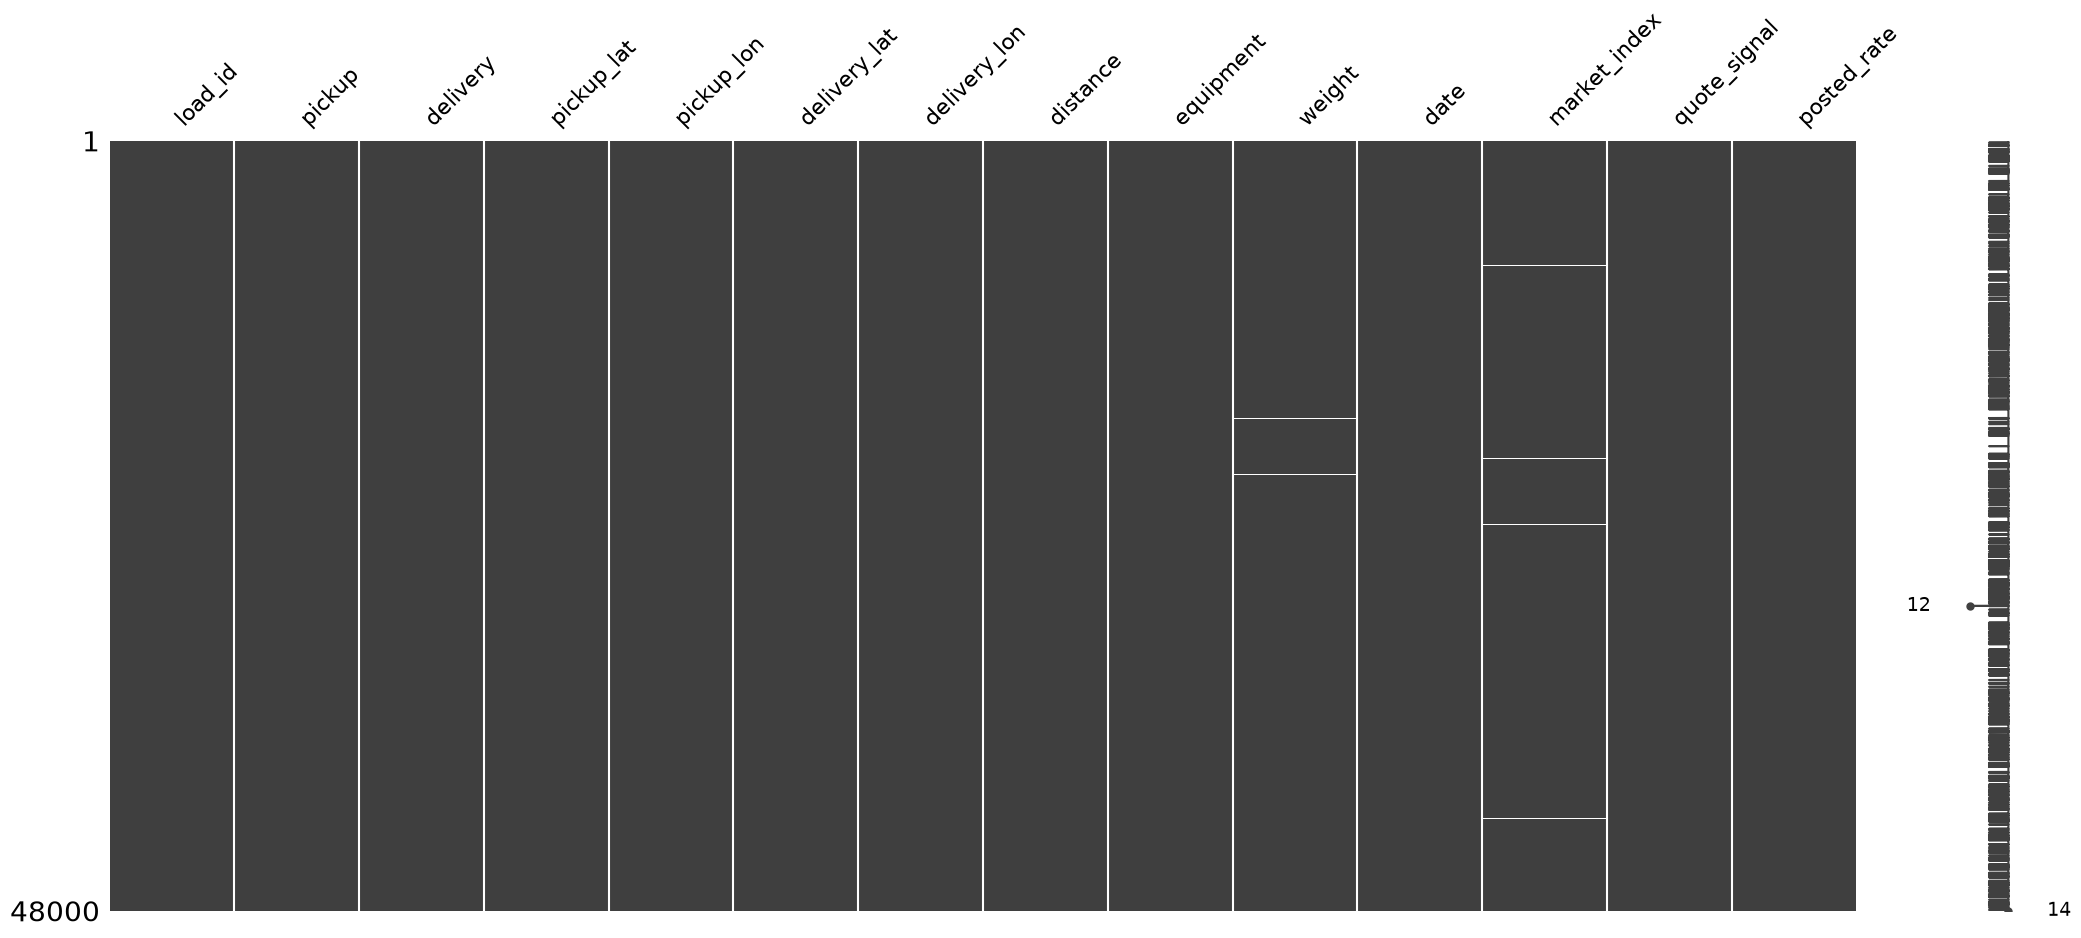

In [216]:
msno.matrix(df); # missing completely at random (MCAR)

In [217]:
df.isnull().sum() # missing values

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

In [218]:
df.nunique()    

load_id         48000
pickup             64
delivery           64
pickup_lat         64
pickup_lon         63
delivery_lat       64
delivery_lon       63
distance        21204
equipment           3
weight          23678
date              304
market_index    32884
quote_signal    37633
posted_rate     45398
dtype: int64

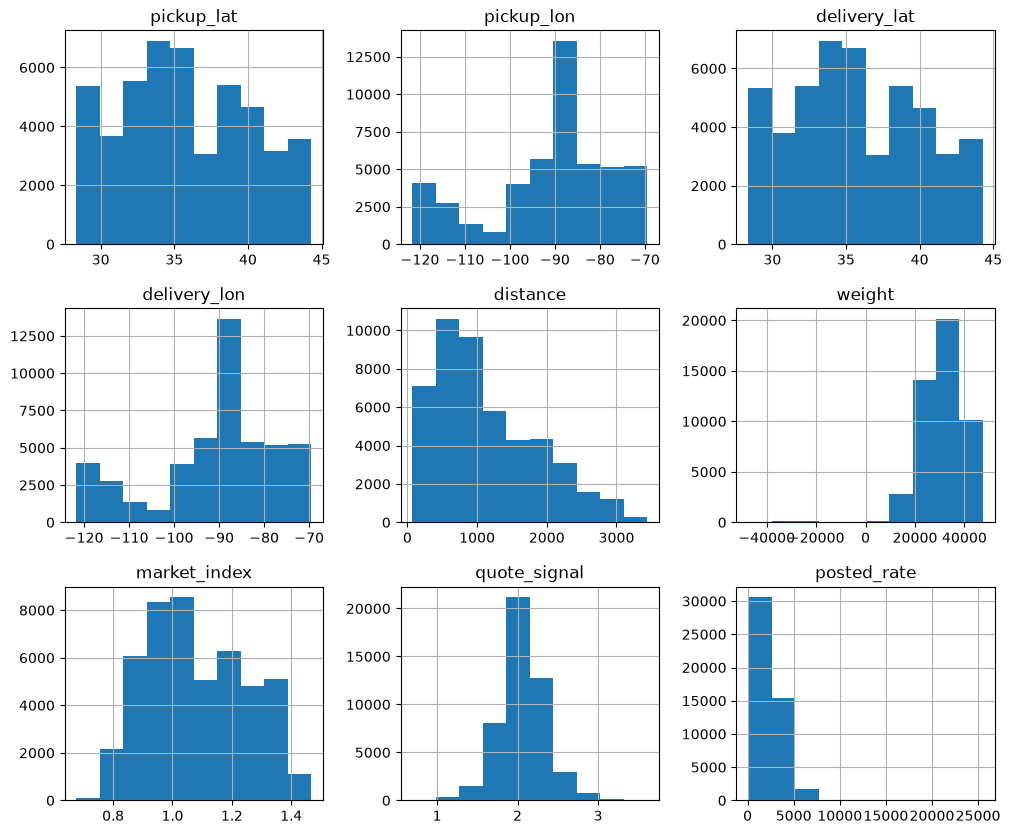

In [219]:
df.hist(figsize=(12,10));

In [220]:
df.skew(numeric_only=True)

pickup_lat      0.177336
pickup_lon     -0.693987
delivery_lat    0.179351
delivery_lon   -0.699329
distance        0.765775
weight         -1.910391
market_index    0.214263
quote_signal    0.171989
posted_rate     1.902395
dtype: float64

In [221]:
#Data Cleaning

# Fix weight sign-flip errors
negative_count = (df['weight'] < 0).sum()
df['weight'] = df['weight'].abs()
print(f" Fixed {negative_count} weight sign-flip errors")

 Fixed 292 weight sign-flip errors


In [222]:
# Drop rows with missing weight or market_index
# (Only 0.62% and 0.78% missing — safe to drop from training data)
rows_before = len(df)
df = df.dropna(subset=['weight', 'market_index'])
rows_after = len(df)
print(f"Dropped {rows_before - rows_after} rows with missing weight/market_index")
print(f"Training data remaining: {rows_after:,} rows")

Dropped 673 rows with missing weight/market_index
Training data remaining: 47,327 rows


In [223]:
df.duplicated().sum()  

np.int64(0)

In [224]:
df.groupby('equipment')['posted_rate'].describe()

,count,mean,std,min,25%,50%,75%,max
equipment,,,,,,,,
Dry Van,26825.0,2271.650920,1423.704969,57.22,1196.1000,1952.91,3193.750,25533.00
Flatbed,8626.0,2445.950822,1507.033198,157.76,1290.1925,2075.53,3471.160,17893.17
Reefer,11876.0,2552.759440,1590.821439,63.36,1361.5475,2195.79,3585.295,24140.21


In [225]:
df.groupby(['equipment', 'pickup'])['posted_rate'].mean()

equipment  pickup     
Dry Van    Albany         2841.927331
           Albuquerque    2745.871749
           Amarillo       2493.015336
           Atlanta        1712.501031
           Austin         2239.500219
                             ...     
Reefer     Tampa          2379.714048
           Toledo         2283.598424
           Tucson         3436.513275
           Tulsa          2085.590920
           Washington     2232.769655
Name: posted_rate, Length: 192, dtype: float64

In [226]:
df.groupby('equipment')['posted_rate'].mean().sort_values(ascending=False)

equipment
Reefer     2552.759440
Flatbed    2445.950822
Dry Van    2271.650920
Name: posted_rate, dtype: float64

In [227]:
def engineer_features(data):

    data = data.copy()

    data['date']        = pd.to_datetime(data['date'])
    data['month']       = data['date'].dt.month          # 1-12: to check seasonality
    data['week']        = data['date'].dt.isocalendar().week.astype(int)  # 1-52
    data['day_of_week'] = data['date'].dt.dayofweek      # 0=Monday, 6=Sunday
    data['quarter']     = data['date'].dt.quarter         # 1-4

    return data


# Apply to both training and production data
df      = engineer_features(df)
df_prod = engineer_features(df_prod)

print(f"Engineered features: month, week, day_of_week, quarter")
print(f"  month range:       {df['month'].min()} - {df['month'].max()}")
print(f"  week range:        {df['week'].min()} - {df['week'].max()}")
print(f"  day_of_week range: {df['day_of_week'].min()} - {df['day_of_week'].max()}")
print(f"  quarter range:     {df['quarter'].min()} - {df['quarter'].max()}")

Engineered features: month, week, day_of_week, quarter
  month range:       1 - 10
  week range:        1 - 44
  day_of_week range: 0 - 6
  quarter range:     1 - 4


In [228]:
df['rate_per_mile'] = df['posted_rate'] / df['distance']

print("rate_per_mile stats:")
print(df['rate_per_mile'].describe())

rate_per_mile stats:
count    47327.000000
mean         2.215905
std          0.586368
min          0.333709
25%          1.987034
50%          2.145752
75%          2.342888
max         14.125294
Name: rate_per_mile, dtype: float64


In [229]:
# Weekly Seasonality

# difference between LOWEST weekly average and HIGHEST weekly average
min_week = weekly.min()   # lowest week  (January)
max_week = weekly.max()   # highest week (late June / early July)

swing_pct = ((max_week - min_week) / min_week) * 100

print(f"\n16% SEASONAL SWING CALCULATION:")
print(f"  Lowest weekly avg:  ${min_week:.4f}/mile  → {weekly.idxmin().strftime('%Y-%m-%d')}")
print(f"  Highest weekly avg: ${max_week:.4f}/mile  → {weekly.idxmax().strftime('%Y-%m-%d')}")
print(f"  Formula: ((max - min) / min) × 100")
print(f"           (({max_week:.4f} - {min_week:.4f}) / {min_week:.4f}) × 100")
print(f"  Result:  {swing_pct:.1f}% diffence in weekly seasonality")


16% SEASONAL SWING CALCULATION:
  Lowest weekly avg:  $2.0586/mile  → 2025-01-05
  Highest weekly avg: $2.3908/mile  → 2025-06-29
  Formula: ((max - min) / min) × 100
           ((2.3908 - 2.0586) / 2.0586) × 100
  Result:  16.1% diffence in weekly seasonality


In [230]:
#Monthly average per mile

monthly = df.groupby(df['date'].dt.month)['rate_per_mile'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct']

print(f"\nMonthly average rate_per_mile:")
for month, rate in monthly.items():
    print(f"  {month_names[month-1]}: ${rate:.4f}/mile")


Monthly average rate_per_mile:
  Jan: $2.1001/mile
  Feb: $2.1236/mile
  Mar: $2.2067/mile
  Apr: $2.2105/mile
  May: $2.2607/mile
  Jun: $2.3326/mile
  Jul: $2.2558/mile
  Aug: $2.1895/mile
  Sep: $2.2309/mile
  Oct: $2.2412/mile


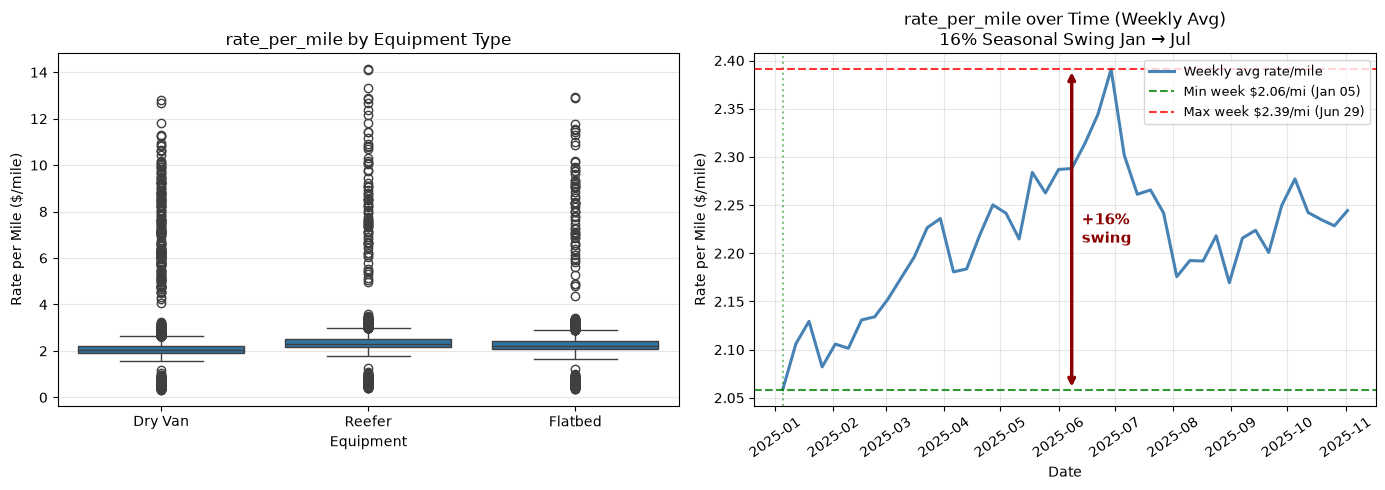

Saved: equip_time.png


In [231]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT CHART: Rate per mile by equipment type 
sns.boxplot(data=df, x='equipment', y='rate_per_mile',
            ax=axes[0])
axes[0].set_title('rate_per_mile by Equipment Type')
axes[0].set_ylabel('Rate per Mile ($/mile)')
axes[0].set_xlabel('Equipment')
axes[0].grid(axis='y', alpha=0.3)

# RIGHT CHART: Weekly trend with 16% swing 
axes[1].plot(weekly.index, weekly.values,
             color='steelblue', linewidth=2.2, label='Weekly avg rate/mile')

# Shade the Jan start area
jan_weeks = weekly[weekly.index.month == 1]
axes[1].axvline(x=jan_weeks.index[0], color='green', linestyle=':', alpha=0.5)

# Horizontal lines for min and max
axes[1].axhline(y=min_week, color='green', linestyle='--', linewidth=1.5,
                label=f'Min week ${min_week:.2f}/mi ({weekly.idxmin().strftime("%b %d")})',
                alpha=0.8)
axes[1].axhline(y=max_week, color='red', linestyle='--', linewidth=1.5,
                label=f'Max week ${max_week:.2f}/mi ({weekly.idxmax().strftime("%b %d")})',
                alpha=0.8)

#showing the 16% swing
mid_date = weekly.index[len(weekly)//2]
axes[1].annotate('',
                 xy=(mid_date, max_week),
                 xytext=(mid_date, min_week),
                 arrowprops=dict(arrowstyle='<->', color='darkred', lw=2.5))
axes[1].text(mid_date, (min_week + max_week) / 2,
             f'  +{swing_pct:.0f}%\n  swing',
             color='darkred', fontsize=11, fontweight='bold', va='center')

axes[1].set_title(f'rate_per_mile over Time (Weekly Avg)\n{swing_pct:.0f}% Seasonal Swing Jan → Jul')
axes[1].set_ylabel('Rate per Mile ($/mile)')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig('equip_time.png', dpi=110, bbox_inches='tight')
plt.show()
print("Saved: equip_time.png")

In [232]:
# Split x and y
# Features to use in the model
# Excluded: load_id (identifier), pickup/delivery text (redundant with distance),
#           lat/lon (tested — no added value over distance), date (engineered above)
# Target:   posted_rate (what we predict)

FEATURES    = [
    'distance',      # strongest predictor (0.91 correlation with target)
    'weight',        # load weight
    'market_index',  # market condition signal
    'quote_signal',  # pricing signal
    'equipment',     # truck type (Dry Van, Reefer, Flatbed)
    'month',         # seasonal pattern
    'week',          # sub-seasonal pattern
    'day_of_week',   # weekly pattern
    'quarter'        # quarterly trend
]
IMPUTE_COLS = ['weight', 'market_index']  # columns with missing values
TARGET      = 'posted_rate'

# Separate X, y, and load_ids
y        = df[TARGET]
X        = df[FEATURES].copy()
load_ids = df['load_id']

print(f" Features (X) shape:  {X.shape}")
print(f" Target (y) shape:    {y.shape}")
print(f" load_ids shape:      {load_ids.shape}")
print(f"\nFeatures selected ({len(FEATURES)}):")
for i, feat in enumerate(FEATURES, 1):
    print(f"  {i}. {feat}")

 Features (X) shape:  (47327, 9)
 Target (y) shape:    (47327,)
 load_ids shape:      (47327,)

Features selected (9):
  1. distance
  2. weight
  3. market_index
  4. quote_signal
  5. equipment
  6. month
  7. week
  8. day_of_week
  9. quarter


In [233]:
# Test and Train Split

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, load_ids,
    test_size=0.2,     # 20% goes to test set
    random_state=42    # reproducible split every time
)

print(f"Split complete (80/20, random_state=42)")
print(f"\n  X_train:  {X_train.shape}  ← Model LEARNS from this")
print(f"  X_test:   {X_test.shape}   ← Model is EVALUATED on this")
print(f"  y_train:  {y_train.shape}")
print(f"  y_test:   {y_test.shape}")
print(f"  id_train: {id_train.shape}")
print(f"  id_test:  {id_test.shape}")

Split complete (80/20, random_state=42)

  X_train:  (37861, 9)  ← Model LEARNS from this
  X_test:   (9466, 9)   ← Model is EVALUATED on this
  y_train:  (37861,)
  y_test:   (9466,)
  id_train: (37861,)
  id_test:  (9466,)


In [191]:
# Verify zero overlap between train and test

overlap = len(set(id_train) & set(id_test))
print(f"\n  Overlap check: {overlap} loads in both sets "
      f"({'No data leakage' if overlap == 0 else 'PROBLEM'})")


  Overlap check: 0 loads in both sets (No data leakage!)


In [193]:
# Pre processing of data

# Median Imputation
# (Better than dropping: keeps all rows, needed for production where
#  we cannot drop any of the 12,000 required predictions)
imputer = SimpleImputer(strategy='median')
X_train[IMPUTE_COLS] = imputer.fit_transform(X_train[IMPUTE_COLS])  # fit + transform
X_test[IMPUTE_COLS]  = imputer.transform(X_test[IMPUTE_COLS])       # transform only!

print(f"Imputer fit on training data only")
print(f"  Medians learned:")
print(f"    weight:       {imputer.statistics_[0]:.0f}")
print(f"    market_index: {imputer.statistics_[1]:.4f}")

Imputer fit on training data only
  Medians learned:
    weight:       31483
    market_index: 1.0558


In [198]:
# STEP 2: Label Encoding for equipment column
# (Convert text categories to numbers — ML models require numeric input)
le = LabelEncoder()
X_train['equipment'] = le.fit_transform(X_train['equipment'])  # fit and transform
X_test['equipment']  = le.transform(X_test['equipment'])       # transform only

print(f"\nEncoder fit on training data only")
print(f"  Equipment mapping: {dict(zip(le.classes_, range(len(le.classes_))))}")
print(f"    Dry Van = 0")
print(f"    Flatbed = 1")
print(f"    Reefer  = 2")

# Verify no missing values remain
assert X_train.isnull().sum().sum() == 0, "Missing values in X_train"
assert X_test.isnull().sum().sum() == 0, "Missing values in X_test"
print(f"\n Zero missing values in X_train and X_test")


Encoder fit on training data only
  Equipment mapping: {np.int64(0): 0, np.int64(1): 1, np.int64(2): 2}
    Dry Van = 0
    Flatbed = 1
    Reefer  = 2

 Zero missing values in X_train and X_test


In [205]:
# Model Comparison

# Linear Regression
print("Linear Regression")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
mae_lr    = mean_absolute_error(y_test, y_pred_lr)
r2_lr     = r2_score(y_test, y_pred_lr)
print(f"Done — MAE: ${mae_lr:.2f}  R²: {r2_lr:.4f}")

Linear Regression
Done — MAE: $144.87  R²: 0.8287


In [206]:
# Random Forest

print("Random Forest")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
mae_rf    = mean_absolute_error(y_test, y_pred_rf)
r2_rf     = r2_score(y_test, y_pred_rf)
print(f"Done — MAE: ${mae_rf:.2f}  R²: {r2_rf:.4f}")

Random Forest
Done — MAE: $133.96  R²: 0.8180


In [208]:
# Results --no imputation and dropping (no data prepocessing)

improvement = ((mae_lr - mae_rf) / mae_lr) * 100
print(f"\n  {'Model':<25} {'Test MAE':>10}  {'Test R²':>10}")
print(f"  {'-'*48}")
print(f"  {'Linear Regression':<25} {'$'+str(round(mae_lr,2)):>10}  {r2_lr:>10.4f}")
print(f"  {'Random Forest':<25} {'$'+str(round(mae_rf,2)):>10}  {r2_rf:>10.4f}")
print(f"Random Forest wins by ${mae_lr - mae_rf:.2f} ({improvement:.1f}% better)")
print(f"Using Random Forest for final predictions")


  Model                       Test MAE     Test R²
  ------------------------------------------------
  Linear Regression            $144.87      0.8287
  Random Forest                $133.96      0.8180
Random Forest wins by $10.91 (7.5% better)
Using Random Forest for final predictions


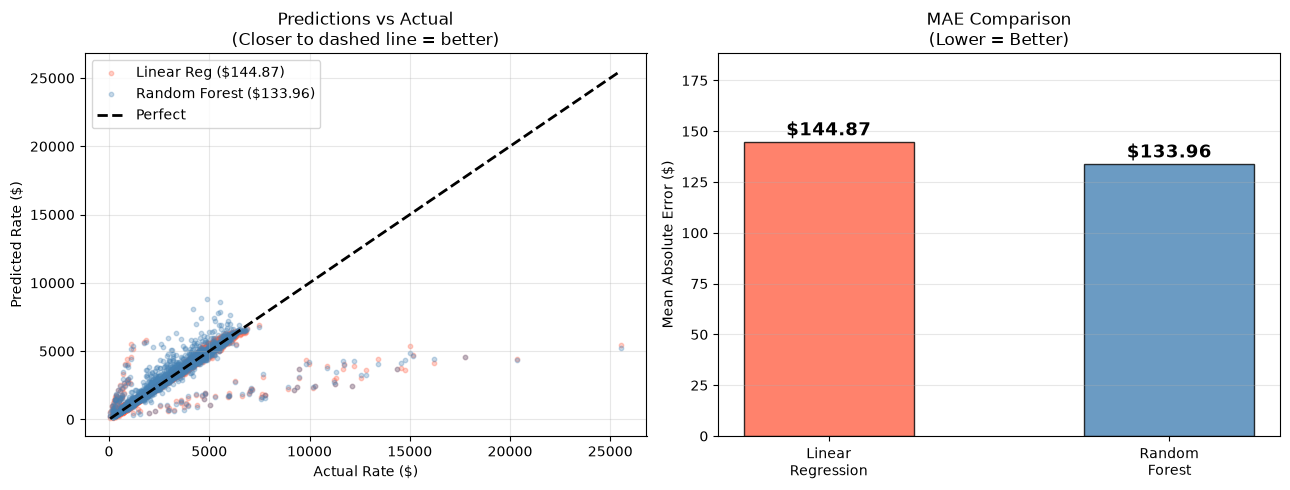

Saved: model_comparison.png


In [210]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predictions vs Actual
axes[0].scatter(y_test, y_pred_lr, alpha=0.3, s=10,
                color='tomato', label=f'Linear Reg (${mae_lr:.2f})')
axes[0].scatter(y_test, y_pred_rf, alpha=0.3, s=10,
                color='steelblue', label=f'Random Forest (${mae_rf:.2f})')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect')
axes[0].set_xlabel('Actual Rate ($)')
axes[0].set_ylabel('Predicted Rate ($)')
axes[0].set_title('Predictions vs Actual\n(Closer to dashed line = better)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE comparison bars
models = ['Linear\nRegression', 'Random\nForest']
maes   = [mae_lr, mae_rf]
colors = ['tomato', 'steelblue']
bars   = axes[1].bar(models, maes, color=colors, alpha=0.8,
                     edgecolor='black', width=0.5)
axes[1].set_ylabel('Mean Absolute Error ($)')
axes[1].set_title('MAE Comparison\n(Lower = Better)')
axes[1].set_ylim(0, max(maes) * 1.3)
axes[1].grid(axis='y', alpha=0.3)

for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., h + 1,
                f'${h:.2f}', ha='center', va='bottom',
                fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=110)
plt.show()
print("Saved: model_comparison.png")